In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("../data/output/anomaly_detection_results.csv")

df.head()

,timestamp,anomaly,CO_GT,NO2_GT,NOx_GT,PT08_S1_CO,PT08_S2_NMHC,PT08_S3_NOx,T,RH,AH
0,2004-03-10 18:00:00,1,0.307758,-0.037558,-0.414742,1.140560,0.372175,0.892583,-0.470560,-0.009173,-0.579294
1,2004-03-10 19:00:00,1,-0.105109,-0.472844,-0.707292,0.829606,0.029389,1.352356,-0.504410,-0.077934,-0.660066
2,2004-03-10 20:00:00,1,0.032514,-0.016830,-0.577270,1.332621,-0.030881,1.219879,-0.662375,0.283065,-0.598299
3,2004-03-10 21:00:00,1,0.032514,0.148994,-0.386880,1.213726,0.003021,1.032852,-0.763925,0.626874,-0.507024
4,2004-03-10 22:00:00,1,-0.380354,0.024626,-0.577270,0.738148,-0.418870,1.473143,-0.741358,0.603953,-0.501772


In [3]:
print("Shape:", df.shape)

df["anomaly"].value_counts()

Shape: (7674, 11)


anomaly
 1    7290
-1     384
Name: count, dtype: int64

In [4]:
total = len(df)
anomalies = (df["anomaly"] == -1).sum()

print(f"Total samples: {total}")
print(f"Detected anomalies: {anomalies}")
print(f"Anomaly percentage: {round(anomalies/total*100, 2)}%")

Total samples: 7674
Detected anomalies: 384
Anomaly percentage: 5.0%


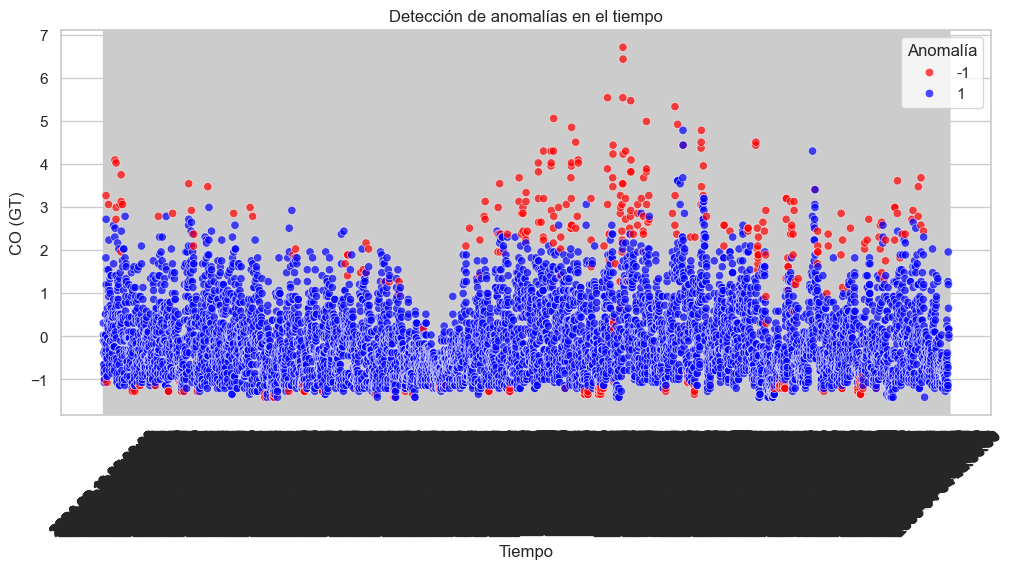

In [5]:
plt.figure(figsize=(12,5))

sns.scatterplot(
    x=df["timestamp"],
    y=df["CO_GT"],
    hue=df["anomaly"],
    palette={1: "blue", -1: "red"},
    alpha=0.7
)

plt.xticks(rotation=45)
plt.title("Anomaly detection over time")
plt.xlabel("Time")
plt.ylabel("CO (GT)")

plt.legend(title="Anomaly")
plt.show()

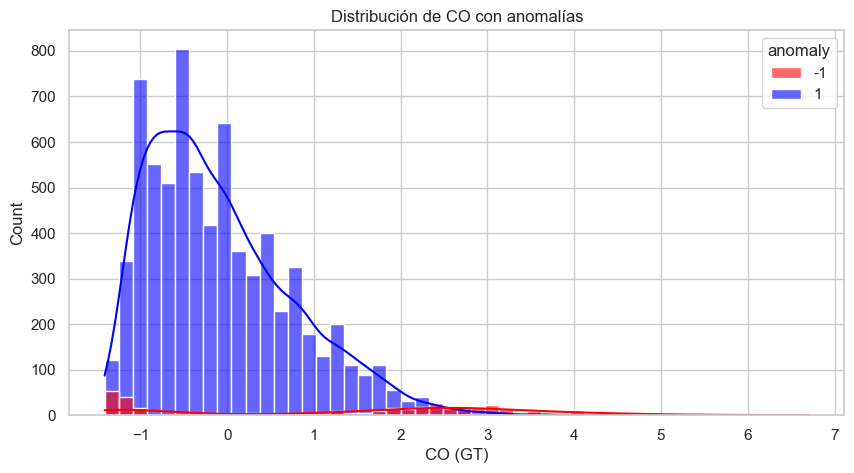

In [6]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="CO_GT",
    hue="anomaly",
    bins=50,
    kde=True,
    palette={1: "blue", -1: "red"},
    alpha=0.6
)

plt.title("CO distribution with anomalies")
plt.xlabel("CO (GT)")
plt.show()

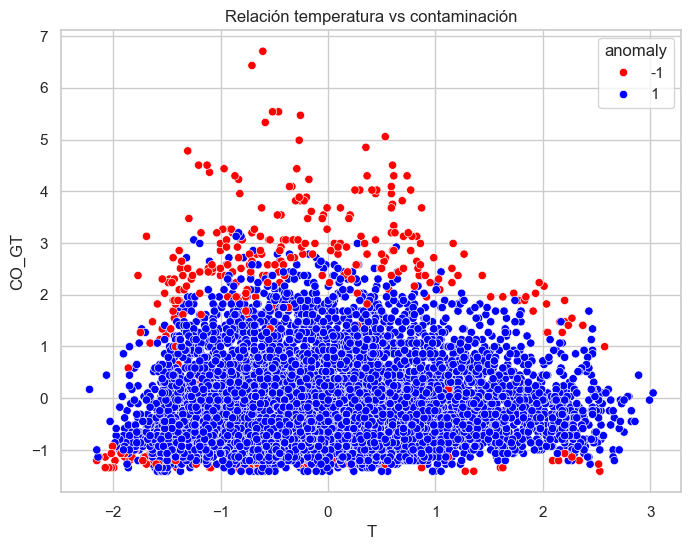

In [7]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="T",
    y="CO_GT",
    hue="anomaly",
    palette={1: "blue", -1: "red"}
)

plt.title("Temperature vs. pollution relationship")
plt.show()

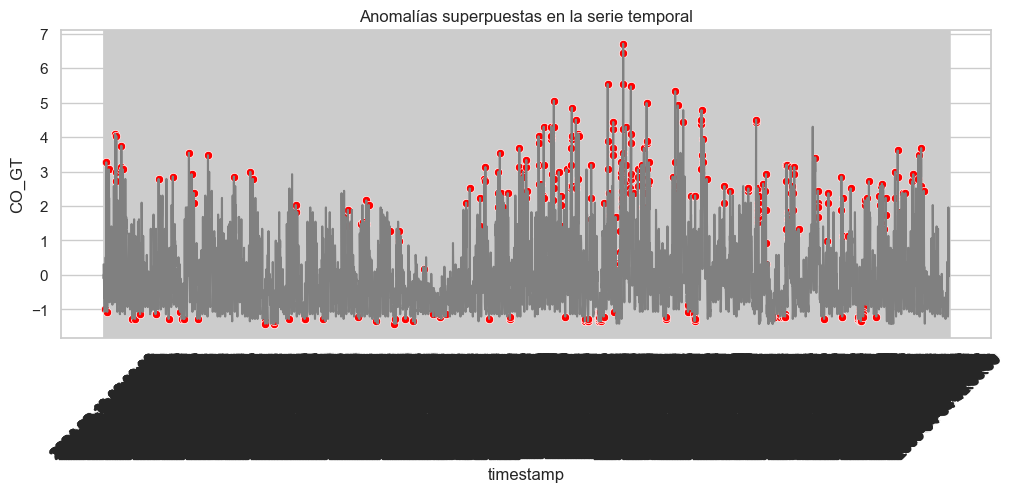

In [8]:
df_sorted = df.sort_values("timestamp")

plt.figure(figsize=(12,4))

sns.lineplot(
    x=df_sorted["timestamp"],
    y=df_sorted["CO_GT"],
    color="gray"
)

# Overlay anomalies
sns.scatterplot(
    x=df_sorted[df_sorted["anomaly"] == -1]["timestamp"],
    y=df_sorted[df_sorted["anomaly"] == -1]["CO_GT"],
    color="red"
)

plt.xticks(rotation=45)
plt.title("Anomalies overlaid on the time series")

plt.show()

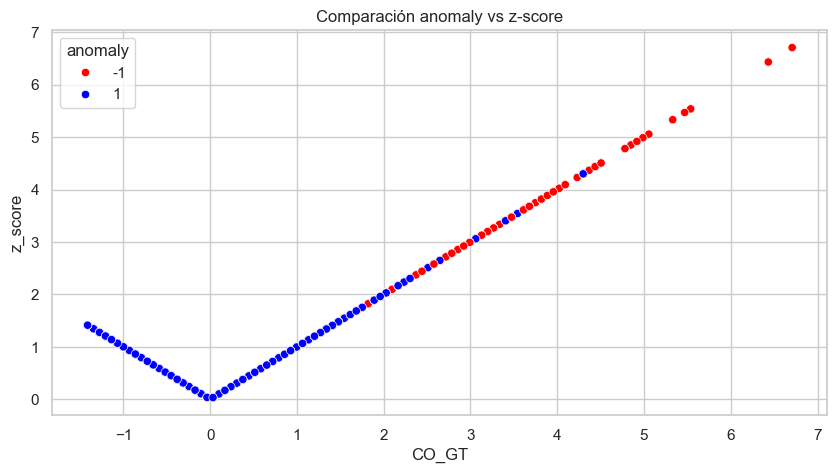

In [9]:
from scipy.stats import zscore

df["z_score"] = np.abs(zscore(df["CO_GT"]))

plt.figure(figsize=(10,5))

sns.scatterplot(
    x=df["CO_GT"],
    y=df["z_score"],
    hue=df["anomaly"],
    palette={1: "blue", -1: "red"}
)

plt.title("Anomaly label vs. z-score comparison")

plt.show()

In [10]:
print("Interpretation:")

if anomalies / total < 0.1:
    print("Low anomaly level: stable system")
else:
    print("High anomaly level: possible irregular behavior")

print("\nThe model detected patterns outside the normal distribution")

Interpretation:
Low anomaly level: stable system

The model detected patterns outside the normal distribution
